In [5]:
import tensorflow as tf
import pandas as pd
import shap
print("TF:", tf.__version__)
print("All good!")

TF: 2.15.0
All good!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import shap

print("All imports successful ✅")
print("TensorFlow:", tf.__version__)

All imports successful ✅
TensorFlow: 2.15.0


In [14]:
print("Shape:", df.shape)
print("\nNull values:", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes.value_counts())
df.head()

Shape: (649, 33)

Null values: 0

Data types:
str      17
int64    16
Name: count, dtype: int64


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


Pass/Fail distribution:
pass
1    549
0    100
Name: count, dtype: int64

Pass rate: 84.6%


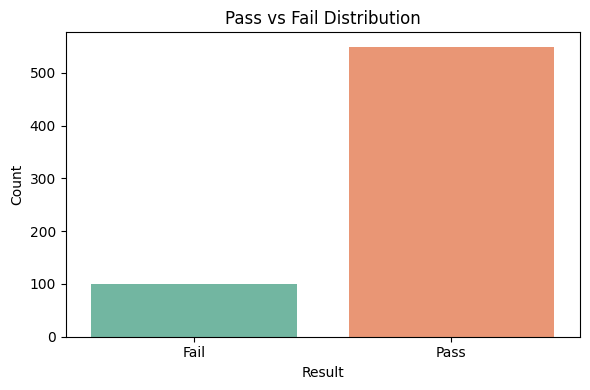

In [15]:
# Create target variable
df['pass'] = (df['G3'] >= 10).astype(int)
print("Pass/Fail distribution:")
print(df['pass'].value_counts())
print(f"\nPass rate: {df['pass'].mean()*100:.1f}%")

# Plot 1 - Pass vs Fail count
plt.figure(figsize=(6,4))
sns.countplot(x='pass', data=df, palette='Set2')
plt.title('Pass vs Fail Distribution')
plt.xticks([0,1], ['Fail', 'Pass'])
plt.xlabel('Result')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

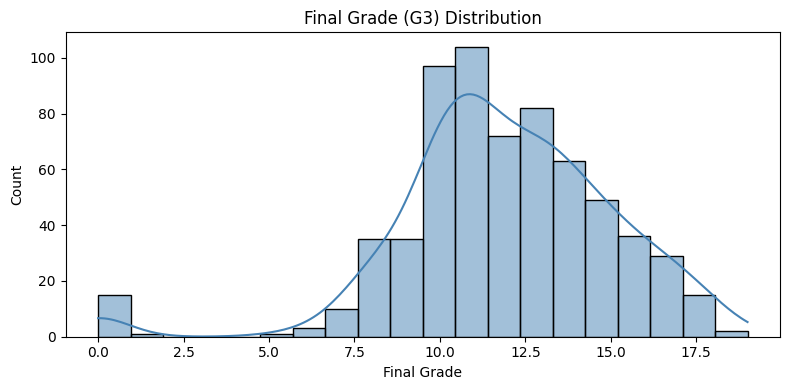

In [16]:
# Plot 2 - G3 grade distribution
plt.figure(figsize=(8,4))
sns.histplot(df['G3'], bins=20, kde=True, color='steelblue')
plt.title('Final Grade (G3) Distribution')
plt.xlabel('Final Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

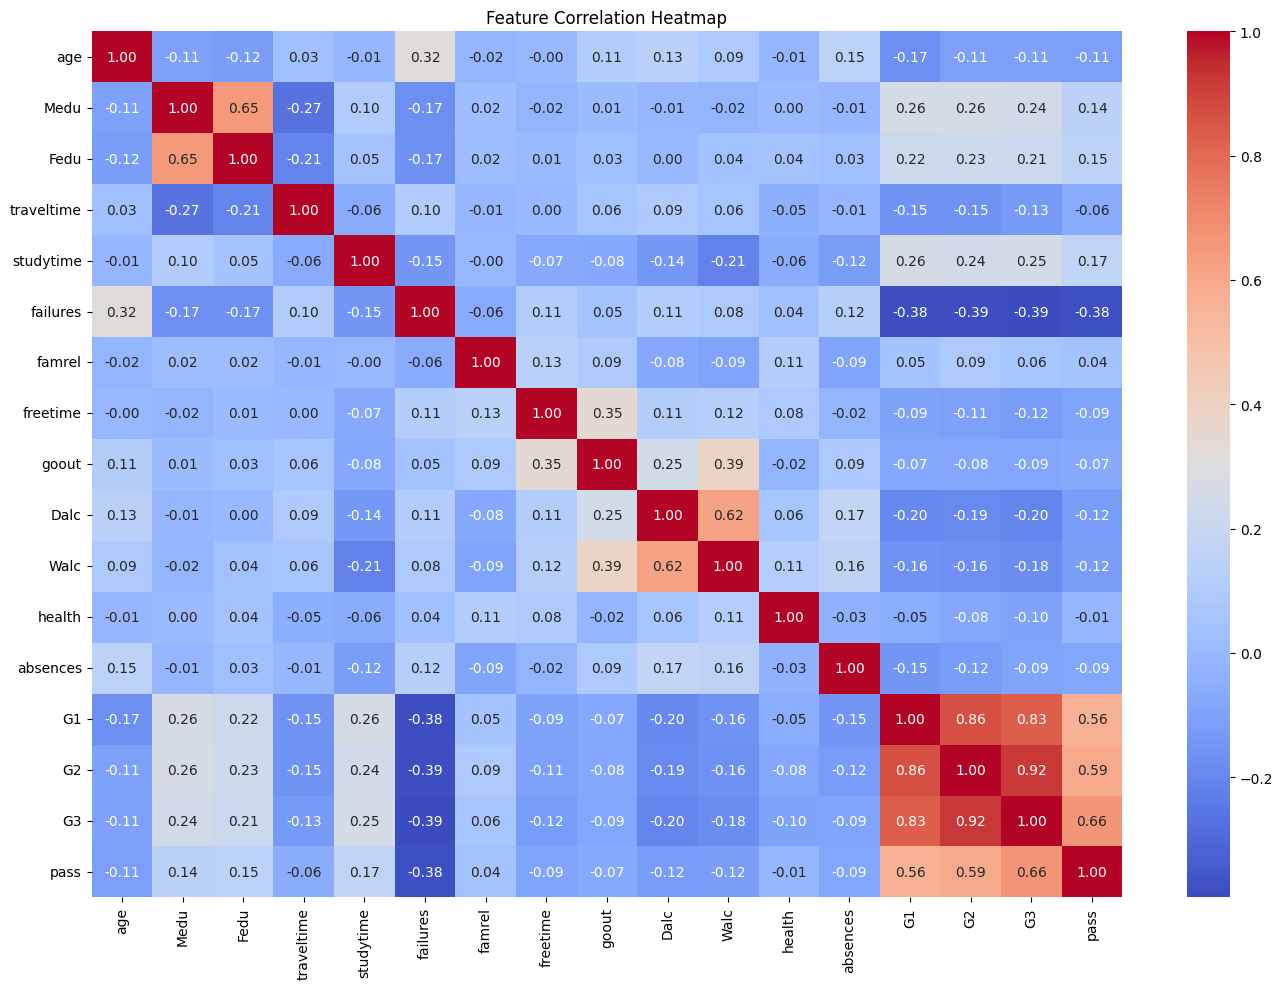

In [17]:
# Plot 3 - Correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

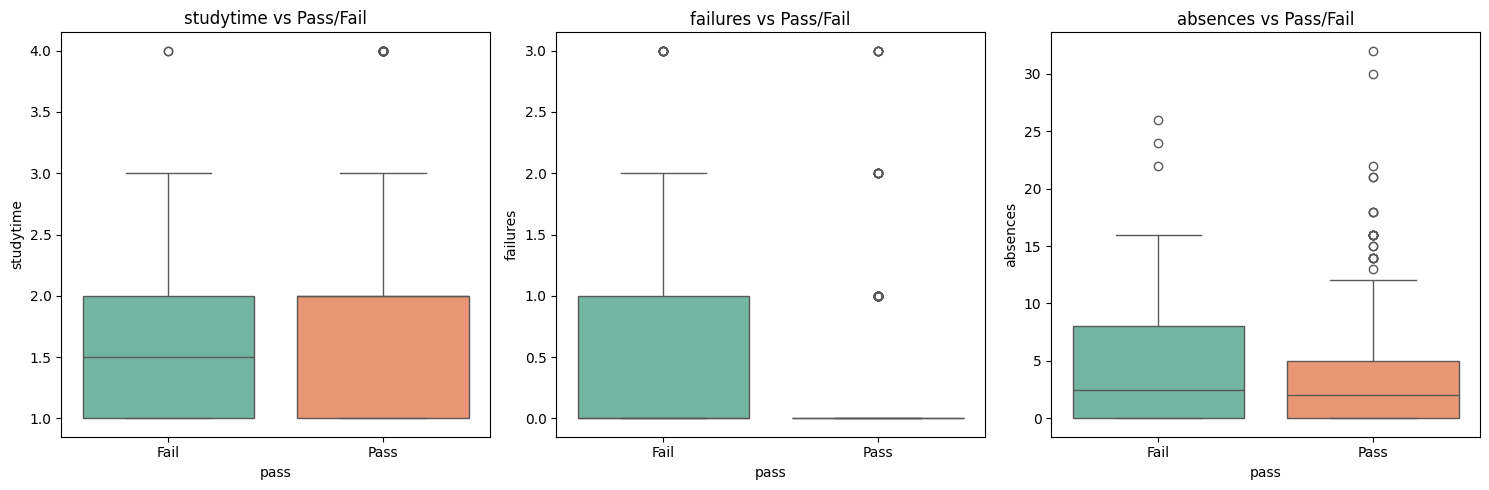

In [18]:
# Plot 4 - Key features vs Pass/Fail
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, col in zip(axes, ['studytime', 'failures', 'absences']):
    sns.boxplot(x='pass', data=df, y=col, palette='Set2', ax=ax)
    ax.set_title(f'{col} vs Pass/Fail')
    ax.set_xticklabels(['Fail', 'Pass'])
plt.tight_layout()
plt.show()

In [19]:
# Drop intermediate grades (data leakage)
df = df.drop(columns=['G1', 'G2'])

# Encode categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop(columns=['G3', 'pass'])
y = df['pass']

print("\nFeature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

# Scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler and feature names for Streamlit app
joblib.dump(scaler, 'app/scaler.pkl')
joblib.dump(list(X.columns), 'app/feature_names.pkl')
print("\n✅ Scaler and feature names saved to app/")

# Split — 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"\nTrain: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Feature shape: (649, 30)
Target distribution:
 pass
1    549
0    100
Name: count, dtype: int64

✅ Scaler and feature names saved to app/

Train: (454, 30)
Val:   (97, 30)
Test:  (98, 30)


In [20]:
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(X_train.shape[1])
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1984      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 4097 (16.00 KB)
Trainable params: 4097 (16.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [21]:
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('app/model.keras', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Model trained and saved to app/model.keras")

Epoch 1/100


29/29 [==============================] - 4s 36ms/step - loss: 0.6109 - accuracy: 0.6850 - val_loss: 0.4530 - val_accuracy: 0.8454
Epoch 2/100
29/29 [==============================] - 0s 13ms/step - loss: 0.4588 - accuracy: 0.8370 - val_loss: 0.4240 - val_accuracy: 0.8454
Epoch 3/100
29/29 [==============================] - 0s 14ms/step - loss: 0.4438 - accuracy: 0.8370 - val_loss: 0.4103 - val_accuracy: 0.8454
Epoch 4/100
29/29 [==============================] - 0s 12ms/step - loss: 0.4213 - accuracy: 0.8370 - val_loss: 0.3997 - val_accuracy: 0.8454
Epoch 5/100
29/29 [==============================] - 0s 13ms/step - loss: 0.3940 - accuracy: 0.8370 - val_loss: 0.3917 - val_accuracy: 0.8454
Epoch 6/100
29/29 [==============================] - 0s 13ms/step - loss: 0.3699 - accuracy: 0.8370 - val_loss: 0.3850 - val_accuracy: 0.8454
Epoch 7/100
29/29 [==============================] - 0s 11ms/step - loss: 0.3999 - accuracy: 0.8370 - val_loss: 0.3764 - val_accuracy: 0.8454
Epoc

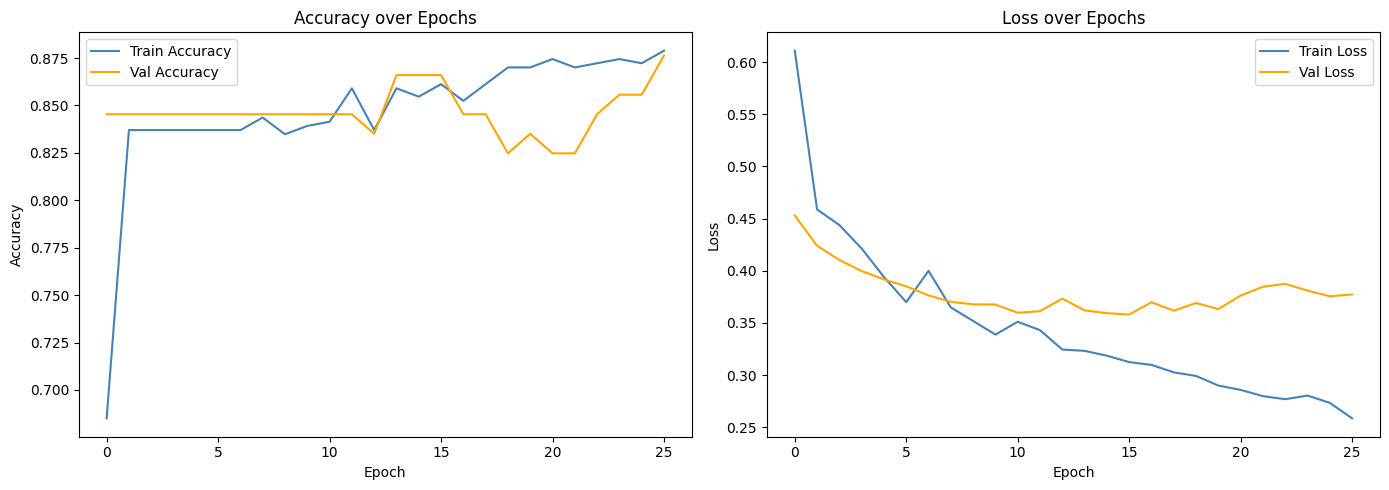

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

4/4 [==============================] - 0s 5ms/step
       NEURAL NETWORK RESULTS
Accuracy:  0.9082

Classification Report:
              precision    recall  f1-score   support

        Fail       0.60      0.55      0.57        11
        Pass       0.94      0.95      0.95        87

    accuracy                           0.91        98
   macro avg       0.77      0.75      0.76        98
weighted avg       0.90      0.91      0.91        98



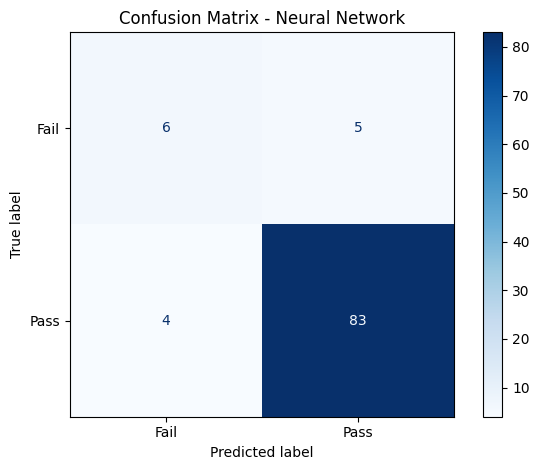

In [23]:
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("=" * 40)
print("       NEURAL NETWORK RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Neural Network')
plt.tight_layout()
plt.show()

    LOGISTIC REGRESSION RESULTS
Accuracy: 0.8980

Classification Report:
              precision    recall  f1-score   support

        Fail       0.57      0.36      0.44        11
        Pass       0.92      0.97      0.94        87

    accuracy                           0.90        98
   macro avg       0.75      0.66      0.69        98
weighted avg       0.88      0.90      0.89        98



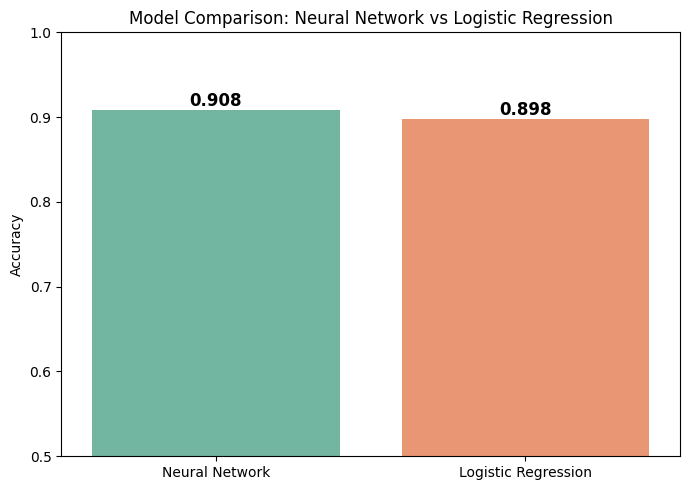


✅ Neural Network outperforms LR by 1.02%


In [24]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=" * 40)
print("    LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Fail', 'Pass']))

# Side by side comparison bar chart
models = ['Neural Network', 'Logistic Regression']
accs = [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_lr)]

plt.figure(figsize=(7,5))
bars = sns.barplot(x=models, y=accs, palette='Set2')
plt.ylim(0.5, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Comparison: Neural Network vs Logistic Regression')
for i, v in enumerate(accs):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n✅ Neural Network outperforms LR by {(accs[0]-accs[1])*100:.2f}%")

Running SHAP analysis... (may take 30-60 seconds)


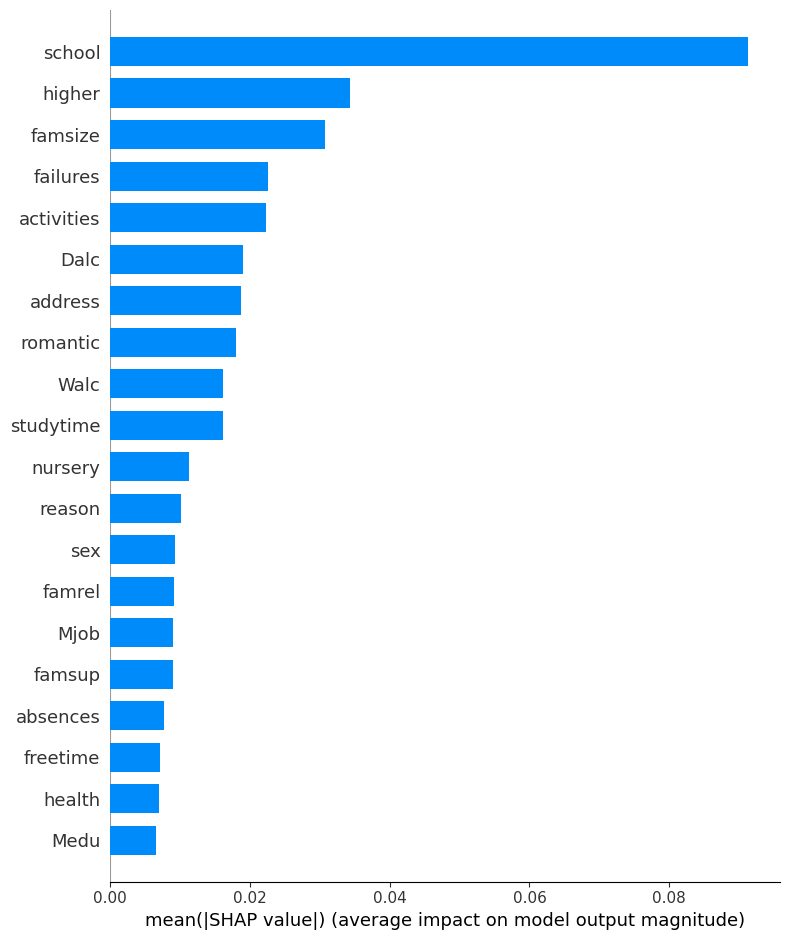

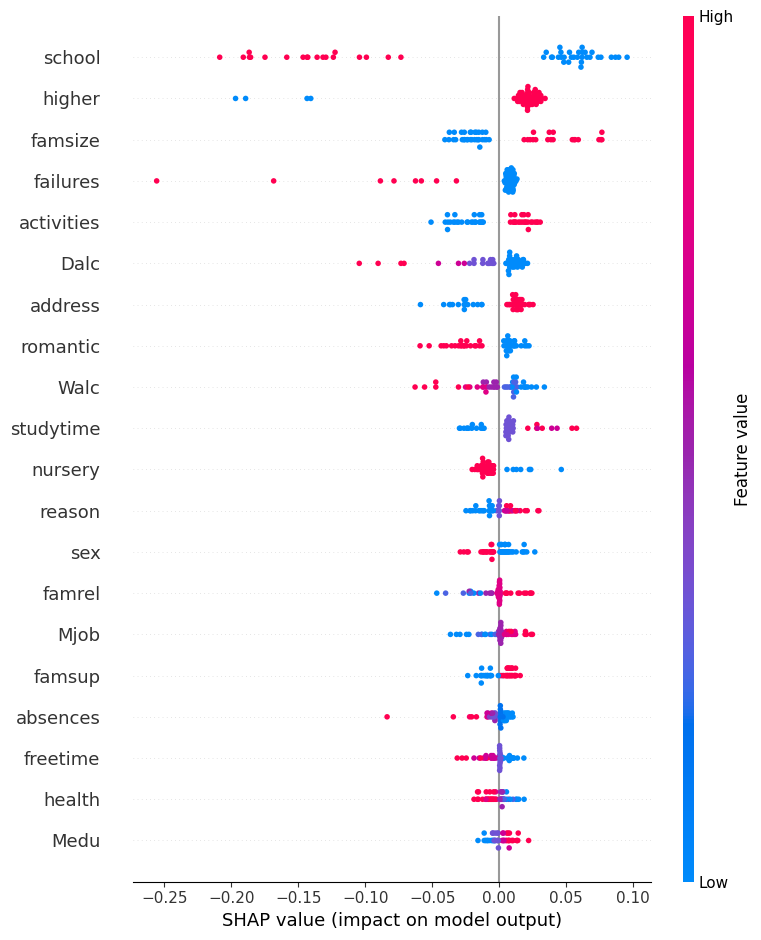


✅ SHAP analysis complete


In [25]:
print("Running SHAP analysis... (may take 30-60 seconds)")

background = X_train[:50]
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(X_test[:50])

# Handle output shape
sv = shap_values[0] if isinstance(shap_values, list) else shap_values
if sv.ndim == 3:
    sv = sv[:, :, 0]

feature_names = list(X.columns)

# Plot 1 - Bar summary
plt.figure()
shap.summary_plot(
    sv,
    X_test[:50],
    feature_names=feature_names,
    plot_type='bar',
    show=True
)

# Plot 2 - Beeswarm
plt.figure()
shap.summary_plot(
    sv,
    X_test[:50],
    feature_names=feature_names,
    show=True
)

print("\n✅ SHAP analysis complete")